`Note: Non-overlapping annual returns`

# Imports and Data Loading
First, we load the required packages and fetch the true target data (`y_true` and `dates`) for the KR dataset from 1971-08-31 to 2025-06-30.

In [17]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

import utils.base_utils as bu
import utils.window_utils as wu

# Configure target series configuration matched to the orchestrator runs
start_date = '1971-08-31'
end_date = '2025-06-30'
OOS_start_idx = pd.Timestamp('1990-01-31')

# For KR yields (annual maturities, holding period = 12 months)
maturities = [str(i) for i in range(12, 121) if i % 12 == 0] 
yields = bu.get_yields(type='kr', start=start_date, end=end_date, maturities=maturities)
xr = bu.get_excess_returns(yields, horizon=12).dropna()

# Standard selected 6 maturities modeled in orchestrator runs
target_maturities = ['24', '36', '48', '60', '84', '120']
y_true = xr[target_maturities].values
dates = xr.index

print(f"y_true shape: {y_true.shape}")
print(f"Dates range: {dates[0].strftime('%Y-%m-%d')} to {dates[-1].strftime('%Y-%m-%d')}")

recession_indicator_path = os.path.join(root_dir, 'data', 'USREC.csv')
recession_indicators = pd.read_csv(recession_indicator_path, index_col=0, parse_dates=True)

y_true shape: (635, 6)
Dates range: 1971-08-31 to 2024-06-30


## Load Orchestrator Runs

Here we pull the `val_loss` (or `trailing_oos`) ensemble forecasts for the two multi-output ANN specifications.

In [18]:
import json
# Paths to the specific orchestrated model runs
forward_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'fwd_ann_3&3_100runs_top10', '20260512_141546') # realtime
macro_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'realtime_kr_1971_08_2025_06_macro_fwd_ann_fwd333_macro32_100runs_top10', '20260430_040715') # realtime
group_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'realtime_kr_1971_08_2025_06_group_ens_ann_fwd33_grp1_100runs_top10', '20260430_032808') # realtime
# macro_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'revised_kr_1971_08_2025_06_macro_fwd_ann_fwd333_macro32_100runs_top10', '20260429_051214') # revised
# group_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'revised_kr_1971_08_2025_06_group_ens_ann_fwd33_grp1_100runs_top10', '20260429_041039') # revised

# Using the val_loss criteria ensembles
# forward_ens = np.load(os.path.join(forward_dir, 'ensemble_forecast_val_loss.npy'))
# macro_ens = np.load(os.path.join(macro_dir, 'ensemble_forecast_val_loss.npy'))
# group_ens = np.load(os.path.join(group_dir, 'ensemble_forecast_val_loss.npy'))

# print(f"Forward ensemble shape: {forward_ens.shape}")
# print(f"Macro ensemble shape: {macro_ens.shape}")
# print(f"Group ensemble shape: {group_ens.shape}")

from utils.orchestrator_runs import load_and_reensemble_run
from utils.orchestrator_utils import compute_top_k_ensemble as compute_trailing_top_k_ensemble

ENSEMBLE_K = 10
TRAILING_LOOKBACK = 120
TRAILING_MIN_HISTORY = 24
TRAILING_REALIZATION_LAG = 11

# Rebuild the k-val_loss ensembles from the checkpoint-derived seed forecasts
forward_ens, forward_topk, forward_forecasts_all, forward_losses_all = load_and_reensemble_run(forward_dir, k=ENSEMBLE_K)
macro_ens, macro_topk, macro_forecasts_all, macro_losses_all = load_and_reensemble_run(macro_dir, k=ENSEMBLE_K)
group_ens, group_topk, group_forecasts_all, group_losses_all = load_and_reensemble_run(group_dir, k=ENSEMBLE_K)

def rebuild_trailing_oos_ensemble(forecasts_arr, losses_arr):
    return compute_trailing_top_k_ensemble(
        forecasts_arr,
        losses_arr,
        ENSEMBLE_K,
        selection_metric="trailing_oos",
        y_true=y_true,
        lookback=TRAILING_LOOKBACK,
        min_history=TRAILING_MIN_HISTORY,
        realization_lag=TRAILING_REALIZATION_LAG,
    )

# Rebuild trailing OOS ensembles with the dedicated trailing selector
forward_ens_tr, forward_topk_tr = rebuild_trailing_oos_ensemble(forward_forecasts_all, forward_losses_all)
macro_ens_tr, macro_topk_tr = rebuild_trailing_oos_ensemble(macro_forecasts_all, macro_losses_all)
group_ens_tr, group_topk_tr = rebuild_trailing_oos_ensemble(group_forecasts_all, group_losses_all)

print(f"Forward trailing ensemble shape: {forward_ens_tr.shape}")
print(f"Macro trailing ensemble shape: {macro_ens_tr.shape}")
print(f"Group trailing ensemble shape: {group_ens_tr.shape}")

Forward trailing ensemble shape: (635, 6)
Macro trailing ensemble shape: (635, 6)
Group trailing ensemble shape: (635, 6)


# r2oos up to 2018:

In [19]:
def get_period_performance(mask, gap):
    # Pass full y_true to preserve the historical mean benchmark length,
    # but apply NaNs to the forecast vectors outside the evaluation mask
    y_t = y_true.copy()
    
    def mask_forecast(forecast):
        f = forecast.copy()
        f[~mask] = np.nan
        return f
    
    # Val loss
    fwd_vl = mask_forecast(forward_ens)
    mac_vl = mask_forecast(macro_ens)
    grp_vl = mask_forecast(group_ens)
    
    # Trailing OOS
    fwd_tr = mask_forecast(forward_ens_tr)
    mac_tr = mask_forecast(macro_ens_tr)
    grp_tr = mask_forecast(group_ens_tr)
    
    def score(fcst_series, i):
        r2 = wu.oos_r2(y_t[:, i], fcst_series, gap=gap)
        try:
            pval = bu.RSZ_Signif(y_t[:, i], fcst_series, gap=gap)
            stars = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.10 else ""
            pval_str = f" ({pval:.3f})"
        except Exception:
            stars = ""
            pval_str = ""
        return f"{r2:.4f}{stars}{pval_str}"
        
    res = []
    for i, mat in enumerate(target_maturities):
        res.append({
            'Maturity': mat,
            'Fwd (Val Loss)': score(fwd_vl[:, i], i),
            'Fwd (Trailing)': score(fwd_tr[:, i], i),
            'Macro (Val Loss)': score(mac_vl[:, i], i),
            'Macro (Trailing)': score(mac_tr[:, i], i),
            'Group (Val Loss)': score(grp_vl[:, i], i),
            'Group (Trailing)': score(grp_tr[:, i], i),
        })
    return pd.DataFrame(res)

mask_2018 = (dates >= pd.Timestamp('1990-01-31')) & (dates <= pd.Timestamp('2018-12-31'))
mask_2025 = (dates >= pd.Timestamp('1990-01-31')) & (dates <= pd.Timestamp('2025-12-31'))
mask_2019_2025 = (dates >= pd.Timestamp('2019-01-31')) & (dates <= pd.Timestamp('2025-12-31'))

df_2018 = get_period_performance(mask_2018, gap=11)
df_2025 = get_period_performance(mask_2025, gap=11)
df_2019_2025 = get_period_performance(mask_2019_2025, gap=11)

from IPython.display import display

print("Performance (R2 OOS) 1990-01-31 to 2018-12-31:")
display(df_2018)

print("\nPerformance (R2 OOS) 1990-01-31 to 2025-06-30:")
display(df_2025)

print("\nPerformance (R2 OOS) 2019-01-31 to 2025-06-30:")
display(df_2019_2025)

print("\nNote: Significance: *** p<0.01, ** p<0.05, * p<0.10 (Clark-West / RSZ test)")

Performance (R2 OOS) 1990-01-31 to 2018-12-31:


,Maturity,Fwd (Val Loss),Fwd (Trailing),Macro (Val Loss),Macro (Trailing),Group (Val Loss),Group (Trailing)
0,24,-0.3439 (0.931),-0.1131 (0.497),-0.1182** (0.033),-0.0260** (0.020),-0.0984 (0.171),-0.0218 (0.177)
1,36,-0.2129 (0.773),-0.0563 (0.267),-0.0408** (0.028),0.0638** (0.010),-0.0382** (0.048),-0.0725 (0.299)
2,48,-0.2064 (0.616),0.0016 (0.168),0.0236** (0.012),0.0568** (0.019),-0.0648* (0.057),-0.0377 (0.257)
3,60,-0.2035 (0.561),-0.0313 (0.190),0.0289** (0.013),0.1132*** (0.005),0.0073** (0.012),0.0161 (0.128)
4,84,-0.0694 (0.229),0.0177 (0.109),0.0875*** (0.006),0.1139*** (0.006),0.0378*** (0.009),-0.0252 (0.187)
5,120,0.0377* (0.053),0.1297*** (0.009),0.1040*** (0.003),0.1090*** (0.005),0.0937*** (0.002),0.0437* (0.054)



Performance (R2 OOS) 1990-01-31 to 2025-06-30:


,Maturity,Fwd (Val Loss),Fwd (Trailing),Macro (Val Loss),Macro (Trailing),Group (Val Loss),Group (Trailing)
0,24,-0.2141 (0.762),-0.0322 (0.236),-0.0573** (0.013),-0.0075** (0.012),-0.0308** (0.040),0.0086* (0.053)
1,36,-0.1388 (0.607),-0.0027 (0.106),-0.0205** (0.016),0.0566*** (0.007),-0.0096** (0.018),-0.0277 (0.160)
2,48,-0.1479 (0.534),0.0285* (0.077),0.0143*** (0.010),0.0442** (0.015),-0.0192** (0.015),-0.0120 (0.123)
3,60,-0.1590 (0.534),-0.0077 (0.119),0.0155** (0.012),0.0968*** (0.003),0.0185*** (0.005),0.0135* (0.097)
4,84,-0.0496 (0.193),0.0475** (0.044),0.0609*** (0.006),0.0876*** (0.005),0.0606*** (0.002),-0.0264 (0.145)
5,120,0.0392** (0.037),0.1133*** (0.005),0.0473*** (0.006),0.0682*** (0.009),0.0711*** (0.003),0.0453** (0.025)



Performance (R2 OOS) 2019-01-31 to 2025-06-30:


,Maturity,Fwd (Val Loss),Fwd (Trailing),Macro (Val Loss),Macro (Trailing),Group (Val Loss),Group (Trailing)
0,24,0.1186** (0.049),0.1753** (0.025),0.0990** (0.041),0.0399** (0.042),0.1424** (0.020),0.0865** (0.036)
1,36,0.0717* (0.077),0.1495** (0.016),0.0374* (0.065),0.0362 (0.108),0.0716* (0.069),0.0993** (0.047)
2,48,0.0275 (0.156),0.1095** (0.036),-0.0135 (0.180),0.0064 (0.135),0.1173** (0.037),0.0651* (0.072)
3,60,-0.0201 (0.404),0.0658 (0.110),-0.0262 (0.266),0.0453 (0.121),0.0533* (0.082),0.0051 (0.234)
4,84,0.0129 (0.257),0.1417** (0.019),-0.0235 (0.354),0.0042 (0.262),0.1329** (0.031),-0.0302 (0.267)
5,120,0.0440 (0.140),0.0607 (0.109),-0.1341 (0.658),-0.0625 (0.710),-0.0013 (0.150),0.0505 (0.109)



Note: Significance: *** p<0.01, ** p<0.05, * p<0.10 (Clark-West / RSZ test)


# Certainty equivalence returns (MVO)

Using the forecasting ensembles from above we below compute MVO returns and significance like BBT.

In [20]:
from scipy.optimize import minimize

forecast_panels = {
    "forward": np.asarray(forward_ens_tr, dtype=float),
    "group": np.asarray(group_ens_tr, dtype=float),
    "macro": np.asarray(macro_ens_tr, dtype=float),
}

realized_panel = np.asarray(y_true, dtype=float)
T = min(realized_panel.shape[0], *(panel.shape[0] for panel in forecast_panels.values()))
realized_panel = realized_panel[:T]
forecast_panels = {name: panel[:T] for name, panel in forecast_panels.items()}

risk_aversion = 5.0
lookback = 120
min_history = 24
n_assets = realized_panel.shape[1]
asset_labels = list(target_maturities)


def solve_mvo(mu, cov, gamma=risk_aversion):
    mu = np.asarray(mu, dtype=float)
    cov = np.asarray(cov, dtype=float)
    cov = 0.5 * (cov + cov.T)
    cov = cov + 1e-6 * np.eye(len(mu))

    def objective(weights):
        return -(weights @ mu - 0.5 * gamma * (weights @ cov @ weights))

    def gradient(weights):
        return -(mu - gamma * (cov @ weights))

    constraints = ({"type": "eq", "fun": lambda weights: np.sum(weights) - 1.0, "jac": lambda weights: np.ones_like(weights)},)
    bounds = [(0.0, 1.0)] * len(mu)
    init = np.full(len(mu), 1.0 / len(mu))

    result = minimize(objective, init, method="SLSQP", jac=gradient, bounds=bounds, constraints=constraints)
    if not result.success:
        return init
    return result.x


mvo_paths = {}
for ensemble_name, mu_panel in forecast_panels.items():
    weights = np.full((T, n_assets), np.nan)
    portfolio_returns = np.full(T, np.nan)

    for t in range(T):
        hist_start = max(0, t - lookback)
        hist = realized_panel[hist_start:t]
        hist = hist[~np.isnan(hist).any(axis=1)]
        if hist.shape[0] < min_history:
            continue

        cov = np.cov(hist, rowvar=False)
        cov = np.atleast_2d(cov)
        if cov.shape != (n_assets, n_assets):
            cov = np.cov(hist, rowvar=False, ddof=0)
            cov = np.atleast_2d(cov)
        cov = cov + 1e-6 * np.eye(n_assets)

        mu = mu_panel[t]
        if np.isnan(mu).any():
            continue

        w = solve_mvo(mu, cov)
        weights[t] = w
        portfolio_returns[t] = realized_panel[t] @ w

    mvo_paths[ensemble_name] = {
        "weights": weights,
        "portfolio_returns": portfolio_returns,
        "benchmark_returns": realized_panel @ np.full(n_assets, 1.0 / n_assets),
    }

summary_rows = []
for ensemble_name, path in mvo_paths.items():
    valid = ~np.isnan(path["portfolio_returns"])
    valid_returns = path["portfolio_returns"][valid]
    benchmark_returns = path["benchmark_returns"][valid]

    summary_rows.append(
        {
            "ensemble": ensemble_name,
            "obs": int(valid.sum()),
            "mean_monthly": float(np.nanmean(valid_returns)),
            "vol_monthly": float(np.nanstd(valid_returns, ddof=1)),
            "sharpe_ann": float(np.sqrt(12.0) * np.nanmean(valid_returns) / np.nanstd(valid_returns, ddof=1)),
            "final_wealth": float(np.prod(1.0 + valid_returns)),
        }
    )

mvo_summary = pd.DataFrame(summary_rows).set_index("ensemble")
mvo_summary

,obs,mean_monthly,vol_monthly,sharpe_ann,final_wealth
ensemble,,,,,
forward,414,0.029135,0.068568,1.471927,57437.290218
group,414,0.020300,0.052282,1.345003,2370.856899
macro,414,0.023383,0.058114,1.393808,7257.332616


In [21]:
univariate_panels = {
    "forward": np.asarray(forward_ens_tr, dtype=float),
    "group": np.asarray(group_ens_tr, dtype=float),
    "macro": np.asarray(macro_ens_tr, dtype=float),
}

realized_panel = np.asarray(y_true, dtype=float)
T = min(realized_panel.shape[0], *(panel.shape[0] for panel in univariate_panels.values()))
realized_panel = realized_panel[:T]
univariate_panels = {name: panel[:T] for name, panel in univariate_panels.items()}

uv_risk_aversion = 5.0
uv_lookback = 120
uv_min_history = 24
uv_max_weight = 1.0
n_assets = realized_panel.shape[1]
asset_labels = list(target_maturities)


def solve_univariate_weight(mu, variance, gamma=uv_risk_aversion, max_weight=uv_max_weight):
    if not np.isfinite(mu) or not np.isfinite(variance) or variance <= 0:
        return np.nan
    weight = mu / (gamma * variance)
    return float(np.clip(weight, 0.0, max_weight))


univariate_paths = {}
for ensemble_name, mu_panel in univariate_panels.items():
    weights = np.full((T, n_assets), np.nan)
    portfolio_returns = np.full((T, n_assets), np.nan)
    ceq_returns = np.full((T, n_assets), np.nan)

    for t in range(T):
        hist_start = max(0, t - uv_lookback)
        hist = realized_panel[hist_start:t]
        hist = hist[~np.isnan(hist).any(axis=1)]
        if hist.shape[0] < uv_min_history:
            continue

        variances = np.nanvar(hist, axis=0, ddof=1)
        mu = mu_panel[t]
        if np.isnan(mu).any():
            continue

        for m in range(n_assets):
            weight = solve_univariate_weight(mu[m], variances[m])
            if np.isnan(weight):
                continue
            weights[t, m] = weight
            portfolio_returns[t, m] = weight * realized_panel[t, m]
            ceq_returns[t, m] = weight * mu[m] - 0.5 * uv_risk_aversion * (weight ** 2) * variances[m]

    univariate_paths[ensemble_name] = {
        "weights": weights,
        "portfolio_returns": portfolio_returns,
        "ceq_returns": ceq_returns,
    }

summary_rows = []
for ensemble_name, path in univariate_paths.items():
    for m, maturity in enumerate(asset_labels):
        valid = ~np.isnan(path["portfolio_returns"][:, m])
        valid_returns = path["portfolio_returns"][valid, m]
        valid_ceq = path["ceq_returns"][valid, m]
        valid_weights = path["weights"][valid, m]

        summary_rows.append(
            {
                "ensemble": ensemble_name,
                "maturity": maturity,
                "obs": int(valid.sum()),
                "mean_monthly": float(np.nanmean(valid_returns)),
                "vol_monthly": float(np.nanstd(valid_returns, ddof=1)),
                "sharpe_ann": float(np.sqrt(12.0) * np.nanmean(valid_returns) / np.nanstd(valid_returns, ddof=1)),
                "mean_ceq": float(np.nanmean(valid_ceq)),
                "avg_weight": float(np.nanmean(valid_weights)),
            }
        )

univariate_summary = pd.DataFrame(summary_rows).set_index(["ensemble", "maturity"])
univariate_summary

obs  mean_monthly  vol_monthly  sharpe_ann  mean_ceq  \
ensemble maturity                                                         
forward  24        414      0.004775     0.013054    1.267035  0.006680   
         36        414      0.009900     0.024472    1.401395  0.012500   
         48        414      0.014685     0.034200    1.487475  0.015993   
         60        414      0.016944     0.042721    1.373911  0.018530   
         84        414      0.022041     0.054964    1.389121  0.019980   
         120       414      0.030055     0.072628    1.433505  0.025767   
group    24        414      0.004692     0.013040    1.246295  0.004033   
         36        414      0.006791     0.022580    1.041819  0.006802   
         48        414      0.011555     0.031860    1.256354  0.009015   
         60        414      0.013587     0.039274    1.198394  0.010378   
         84        414      0.014572     0.048260    1.046007  0.013618   
         120       414      0.017486     0.056725    1.067816  0.011350   
macro    24        414      0.004900     0.013167    1.289249  0.006663   
         36        414      0.009183     0.024426    1.302338  0.010908   
         48        414      0.012849     0.033826    1.315866  0.014323   
         60        414      0.016050     0.041036    1.354906  0.016022   
         84        414      0.019679     0.053109    1.283608  0.019066   
         120       414      0.020065     0.060857    1.142159  0.018622   

                   avg_weight  
ensemble maturity              
forward  24          0.922961  
         36          0.908314  
         48          0.903986  
         60          0.896744  
         84          0.810285  
         120         0.834104  
group    24          0.799051  
         36          0.726252  
         48          0.720754  
         60          0.683898  
         84          0.656477  
         120         0.549754  
macro    24          0.927379  
         36          0.913591  
         48          0.876350  
         60          0.826874  
         84          0.751317  
         120         0.604460

## Bianchi-style univariate CER (per maturity)

Following Bianchi, Büchner and Tamoni (2021, RFS — *Bond Risk Premiums with Machine Learning*), we evaluate the economic value of each ensemble forecast through a univariate mean-variance investor who chooses, for every maturity \(m\) separately, a bond portfolio weight at every forecast date \(t\).

**Strict real-time, non-overlapping annual setting.** \(y_t^{(m)}\) is the realized 12-month-ahead excess return on the \(m\)-month bond. At time \(t\), only realizations with \(\tau + 12 \le t\) (equivalently \(\tau \le t-12\)) are known. We use the project-wide convention `gap = 11`.

**Forecasts (already produced — no retraining).** For each maturity \(m\):

- model forecast \(\hat r^{(m,s)}_{t+12|t}\): the top-10 ensemble from the orchestrator runs (both val-loss and trailing-OOS selection rules are reported);
- benchmark \(\hat r^{(m,\text{HM})}_{t+12|t}\): the strict real-time expanding historical mean,
$$\hat r^{(m,\text{HM})}_{t+12|t} = \frac{1}{|\{\tau: \tau \le t-12\}|}\sum_{\tau \le t-12} y_\tau^{(m)}.$$

**Conditional variance (real-time, expanding window of past forecast errors).** Separately for the model and the benchmark,
$$\hat\sigma^{2(m,s)}_{t} = \operatorname{Var}\big(y_\tau^{(m)} - \hat r^{(m,s)}_{\tau+12|\tau}\big)_{\tau \le t-12},$$
requiring at least `min_history = 24` valid past errors before any portfolio decision is made.

**Portfolio weight.** With risk aversion \(\gamma = 5\),
$$w^{(m,s)}_{t} = \operatorname{clip}\!\left(\frac{\hat r^{(m,s)}_{t+12|t}}{\gamma\,\hat\sigma^{2(m,s)}_{t}}, w_{\text{lo}}, w_{\text{hi}}\right),$$
with main bounds \(w \in [-1, 2]\) and a long-only robustness check \(w \in [0, 1]\) below.

**Realized MV utility on the next-12M return.**
$$u^{(m,s)}_{t+12} = w^{(m,s)}_{t}\, y_t^{(m)} - \tfrac{\gamma}{2}\big(w^{(m,s)}_{t}\big)^2 \hat\sigma^{2(m,s)}_{t}.$$

**CER gain in percent.** With annualization factor \(A=1\) because each \(y_t^{(m)}\) is already a 12-month return,
$$\text{CER}^{(m,s)} = 100 \cdot A \cdot \big(\bar u^{(m,s)} - \bar u^{(m,\text{HM})}\big).$$

This is implemented from scratch below — independent of the MVO and CEQ code above.

In [22]:
# Bianchi-style univariate mean-variance CER per maturity.
# Strict real-time: at time t, only y_true[tau] with tau <= t - 12 are observable.

GAMMA_CER = 5.0
A_ANNUAL = 1.0            # 12-month returns -> A = 1 (no further annualization)
CER_GAP = 11              # project-wide non-overlap convention; last observed tau is t - 12
CER_MIN_HISTORY = 12      # minimum past errors before variance is usable (one annual cycle for h=12 forecasts)
BBT_EWMA_ALPHA = 0.05     # BBT (2021) variance estimator: EWMA of squared forecast errors, alpha=0.05 (Thornton-Valente 2012)
WEIGHT_BOUNDS_MAIN = (-1.0, 2.0)
WEIGHT_BOUNDS_LONG_ONLY = (0.0, 1.0)

cer_forecasts = {
    "Forward-only (Val Loss)":   forward_ens,
    "Macro-forward (Val Loss)":  macro_ens,
    "Group-ensemble (Val Loss)": group_ens,
}

y_panel = np.asarray(y_true, dtype=float)
T_cer, n_mat_cer = y_panel.shape


def realtime_hist_mean(y_arr, gap=CER_GAP):
    """Expanding historical-mean benchmark using only returns realized by time t."""
    T = y_arr.shape[0]
    hm = np.full_like(y_arr, np.nan, dtype=float)
    for t in range(1, T):
        end = t - gap
        if end >= 1:
            past = y_arr[:end]
            if np.any(~np.isnan(past), axis=0).all():
                hm[t] = np.nanmean(past, axis=0)
    return hm


def forecast_error_variance(errors, gap=CER_GAP, min_history=CER_MIN_HISTORY, estimator="expanding", alpha=BBT_EWMA_ALPHA):
    """At time t, sample (co)variance of forecast errors {e_tau : tau <= t - gap - 1}.

    estimator='expanding' -> simple expanding-sample variance of past errors (ddof=1)
    estimator='bbt_ewma'  -> EWMA of squared errors with decay alpha (BBT 2021 / Thornton-Valente 2012):
                             sigma^2_t = sum_l alpha * (1-alpha)^l * eps_{t-1-l}^2 (normalized over available past errors)
    """
    if estimator not in {"expanding", "bbt_ewma"}:
        raise ValueError(f"Unknown estimator '{estimator}'")
    T = errors.shape[0]
    var = np.full(T, np.nan, dtype=float)
    for t in range(T):
        end = t - gap
        if end < 1:
            continue
        past = errors[:end]
        past = past[~np.isnan(past)]
        n = past.size
        if n < min_history:
            continue
        if estimator == "expanding":
            var[t] = float(np.var(past, ddof=1))
        else:
            # Newest error gets the highest weight: weight at lag l (0 = newest) is alpha * (1-alpha)^l.
            # past is ordered oldest -> newest, so weight order from oldest is (1-alpha)^(n-1-i).
            weights = alpha * (1.0 - alpha) ** np.arange(n - 1, -1, -1)
            weights = weights / weights.sum()
            var[t] = float(np.sum(weights * past ** 2))
    return var


def mv_utility(weights, realized, variance, gamma=GAMMA_CER):
    return weights * realized - 0.5 * gamma * (weights ** 2) * variance


from scipy.stats import t as _student_t

def dm_hln_pvalue(d, h=12):
    """One-sided DM test with Harvey-Leybourne-Newbold (1997) small-sample correction.

    H0: E[d_t] <= 0, H1: E[d_t] > 0, where d_t = u_model_t - u_bench_t.
    Newey-West HAC variance with Bartlett weights up to lag h-1 (h=12 for annual forecasts).
    Reference: BBT (2021) pp. 1075; HLN (1997) Eq. (9).
    """
    d = np.asarray(d, dtype=float)
    d = d[~np.isnan(d)]
    n = d.size
    if n < max(5, h + 1):
        return np.nan
    d_bar = float(np.mean(d))
    gamma0 = float(np.mean((d - d_bar) ** 2))
    var_d = gamma0
    for k in range(1, h):
        cov_k = float(np.mean((d[k:] - d_bar) * (d[:-k] - d_bar)))
        weight = 1.0 - k / float(h)
        var_d += 2.0 * weight * cov_k
    if not np.isfinite(var_d) or var_d <= 0:
        return np.nan
    dm_stat = d_bar / np.sqrt(var_d / n)
    correction = (n + 1.0 - 2.0 * h + h * (h - 1.0) / n) / n
    if correction <= 0:
        return np.nan
    dm_hln = dm_stat * np.sqrt(correction)
    return float(1.0 - _student_t.cdf(dm_hln, df=n - 1))


def stars_for_pvalue(p):
    if not np.isfinite(p):
        return ""
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""


hm_bench = realtime_hist_mean(y_panel, gap=CER_GAP)


def evaluate_bianchi_cer(forecast_panel, weight_bounds, variance_estimator="expanding"):
    """Per-maturity CER results for one ensemble vs. the historical-mean benchmark."""
    w_lo, w_hi = weight_bounds
    rows = []
    diagnostics = {}
    for m, mat in enumerate(target_maturities):
        f_model = forecast_panel[:, m]
        f_bench = hm_bench[:, m]
        rx = y_panel[:, m]

        err_model = rx - f_model
        err_bench = rx - f_bench

        var_model = forecast_error_variance(err_model, estimator=variance_estimator)
        var_bench = forecast_error_variance(err_bench, estimator=variance_estimator)

        with np.errstate(divide="ignore", invalid="ignore"):
            w_model = f_model / (GAMMA_CER * var_model)
            w_bench = f_bench / (GAMMA_CER * var_bench)
        w_model = np.clip(w_model, w_lo, w_hi)
        w_bench = np.clip(w_bench, w_lo, w_hi)

        u_model = mv_utility(w_model, rx, var_model)
        u_bench = mv_utility(w_bench, rx, var_bench)

        # Strictly real-time evaluation: only count dates where all inputs are observable
        valid = (
            ~np.isnan(f_model)
            & ~np.isnan(f_bench)
            & ~np.isnan(var_model)
            & ~np.isnan(var_bench)
            & ~np.isnan(rx)
        )
        if not valid.any():
            rows.append({
                "Maturity": mat,
                "obs": 0,
                "CER_pct": np.nan,
                "DM_HLN_pval": np.nan,
                "avg_w_model": np.nan,
                "avg_w_bench": np.nan,
            })
            continue

        u_m = float(np.mean(u_model[valid]))
        u_b = float(np.mean(u_bench[valid]))
        d_series = (u_model - u_bench)[valid]
        pval = dm_hln_pvalue(d_series, h=12)
        rows.append({
            "Maturity": mat,
            "obs": int(valid.sum()),
            "CER_pct": 100.0 * A_ANNUAL * (u_m - u_b),
            "DM_HLN_pval": pval,
            "avg_w_model": float(np.mean(w_model[valid])),
            "avg_w_bench": float(np.mean(w_bench[valid])),
        })

        diagnostics[mat] = {
            "weights_model": w_model,
            "weights_bench": w_bench,
            "utility_model": u_model,
            "utility_bench": u_bench,
            "valid_mask": valid,
        }
    return pd.DataFrame(rows), diagnostics


def _format_bbt_cell(cer, pval):
    if not np.isfinite(cer):
        return "\u2014"
    return f"{cer:+.3f}{stars_for_pvalue(pval)}"


def _format_bbt_pval(pval):
    if not np.isfinite(pval):
        return "\u2014"
    return f"({pval:.3f})"


def build_bbt_style_table(full, cer_forecasts, target_maturities):
    """Construct a BBT Table-5 style display: alternating value/p-value rows, maturity columns."""
    row_labels = []
    rows_data = []
    for name in cer_forecasts.keys():
        sub = full.loc[name]
        cer_row = {mat: _format_bbt_cell(sub.loc[mat, "CER_pct"], sub.loc[mat, "DM_HLN_pval"]) for mat in target_maturities}
        pval_row = {mat: _format_bbt_pval(sub.loc[mat, "DM_HLN_pval"]) for mat in target_maturities}
        rows_data.append(cer_row)
        row_labels.append(name)
        rows_data.append(pval_row)
        row_labels.append("  p-value")
    out = pd.DataFrame(rows_data, index=row_labels)
    out.columns = [f"{m}M" for m in target_maturities]
    out.columns.name = "Maturity"
    return out


def collect_cer_table(weight_bounds, label, variance_estimator="expanding"):
    long_rows = []
    diag_store = {}
    for name, fc in cer_forecasts.items():
        df_per_mat, diag = evaluate_bianchi_cer(fc, weight_bounds, variance_estimator=variance_estimator)
        diag_store[name] = diag
        long_rows.append(df_per_mat.assign(Ensemble=name))
    full = pd.concat(long_rows, ignore_index=True).set_index(["Ensemble", "Maturity"])

    all_masks = [d["valid_mask"] for diag in diag_store.values() for d in diag.values() if d["valid_mask"].any()]
    if all_masks:
        common = np.logical_and.reduce(all_masks)
        valid_dates = dates[common]
        window = f"{valid_dates[0].strftime('%Y-%m')} to {valid_dates[-1].strftime('%Y-%m')} ({int(common.sum())} months)"
    else:
        window = "no valid observations"

    if variance_estimator == "expanding":
        var_label = "expanding sample variance of past forecast errors"
    else:
        var_label = f"BBT EWMA of squared forecast errors (alpha={BBT_EWMA_ALPHA})"
    bbt_table = build_bbt_style_table(full, cer_forecasts, target_maturities)
    print(f"{label} | weights in [{weight_bounds[0]}, {weight_bounds[1]}], gamma={GAMMA_CER}, {var_label}")
    print(f"OOS evaluation window: {window}")
    display(bbt_table)
    print("Significance: *** p<0.01, ** p<0.05, * p<0.10 (one-sided DM-HLN test on u_model - u_HM, NW HAC with h-1=11 lags)")
    return full, bbt_table, diag_store


cer_main_df, cer_main_table, _ = collect_cer_table(
    WEIGHT_BOUNDS_MAIN,
    "Univariate CER (% per year) -- expanding-variance version",
    variance_estimator="expanding",
)

print()
cer_main_bbt_df, cer_main_bbt_table, _ = collect_cer_table(
    WEIGHT_BOUNDS_MAIN,
    "BBT-strict univariate CER (% per year) -- EWMA(alpha=0.05) variance",
    variance_estimator="bbt_ewma",
)

Univariate CER (% per year) -- expanding-variance version | weights in [-1.0, 2.0], gamma=5.0, expanding sample variance of past forecast errors
OOS evaluation window: 1991-12 to 2024-06 (391 months)


Maturity,24M,36M,48M,60M,84M,120M
Forward-only (Val Loss),-0.189,+0.141,-0.033,-0.119,+0.314,+0.888
p-value,(0.871),(0.303),(0.532),(0.577),(0.358),(0.237)
Macro-forward (Val Loss),+0.123,+0.462*,+0.732*,+0.853*,+1.330*,+1.710*
p-value,(0.252),(0.062),(0.055),(0.087),(0.073),(0.094)
Group-ensemble (Val Loss),+0.089,+0.481,+0.674,+0.984*,+1.559*,+1.743*
p-value,(0.306),(0.114),(0.110),(0.092),(0.057),(0.100)


Significance: *** p<0.01, ** p<0.05, * p<0.10 (one-sided DM-HLN test on u_model - u_HM, NW HAC with h-1=11 lags)

BBT-strict univariate CER (% per year) -- EWMA(alpha=0.05) variance | weights in [-1.0, 2.0], gamma=5.0, BBT EWMA of squared forecast errors (alpha=0.05)
OOS evaluation window: 1991-12 to 2024-06 (391 months)


Maturity,24M,36M,48M,60M,84M,120M
Forward-only (Val Loss),-0.439,-0.630,-0.853,-1.215,-0.469,+0.519
p-value,(0.997),(0.988),(0.986),(0.976),(0.747),(0.316)
Macro-forward (Val Loss),-0.100,-0.320,-0.104,+0.125,+0.509,+0.766
p-value,(0.716),(0.794),(0.590),(0.400),(0.207),(0.189)
Group-ensemble (Val Loss),-0.184,-0.388,-0.350,+0.066,+0.569,+0.659
p-value,(0.867),(0.813),(0.701),(0.470),(0.289),(0.309)


Significance: *** p<0.01, ** p<0.05, * p<0.10 (one-sided DM-HLN test on u_model - u_HM, NW HAC with h-1=11 lags)


### Robustness: long-only weights \(w \in [0, 1]\)

Same construction as above but with the conservative clip used in some versions of the bond-MV literature. All other inputs (forecasts, real-time historical mean benchmark, expanding error-variance, \(\gamma = 5\), `gap = 11`) are unchanged.

In [23]:
cer_robust_df, cer_robust_table, _ = collect_cer_table(
    WEIGHT_BOUNDS_LONG_ONLY,
    "Long-only robustness CER (% per year) -- expanding variance",
    variance_estimator="expanding",
)

print()
cer_robust_bbt_df, cer_robust_bbt_table, _ = collect_cer_table(
    WEIGHT_BOUNDS_LONG_ONLY,
    "Long-only robustness CER (% per year) -- BBT EWMA(alpha=0.05) variance",
    variance_estimator="bbt_ewma",
)

Long-only robustness CER (% per year) -- expanding variance | weights in [0.0, 1.0], gamma=5.0, expanding sample variance of past forecast errors
OOS evaluation window: 1991-12 to 2024-06 (391 months)


Maturity,24M,36M,48M,60M,84M,120M
Forward-only (Val Loss),-0.094,+0.033,+0.162,+0.243,+0.499,+1.083*
p-value,(0.936),(0.377),(0.140),(0.199),(0.116),(0.059)
Macro-forward (Val Loss),+0.009,+0.087,+0.352**,+0.601***,+0.913**,+1.199**
p-value,(0.440),(0.253),(0.013),(0.005),(0.012),(0.039)
Group-ensemble (Val Loss),-0.001,+0.073,+0.261,+0.636**,+1.152***,+1.629***
p-value,(0.508),(0.321),(0.135),(0.036),(0.007),(0.007)


Significance: *** p<0.01, ** p<0.05, * p<0.10 (one-sided DM-HLN test on u_model - u_HM, NW HAC with h-1=11 lags)

Long-only robustness CER (% per year) -- BBT EWMA(alpha=0.05) variance | weights in [0.0, 1.0], gamma=5.0, BBT EWMA of squared forecast errors (alpha=0.05)
OOS evaluation window: 1991-12 to 2024-06 (391 months)


Maturity,24M,36M,48M,60M,84M,120M
Forward-only (Val Loss),-0.114,-0.115,-0.237,-0.393,-0.160,+0.365
p-value,(0.981),(0.894),(0.928),(0.937),(0.686),(0.267)
Macro-forward (Val Loss),-0.029,-0.083,-0.037,-0.020,+0.245,+0.535
p-value,(0.688),(0.745),(0.584),(0.532),(0.231),(0.130)
Group-ensemble (Val Loss),-0.056,-0.127,-0.154,-0.038,+0.458,+0.768
p-value,(0.837),(0.802),(0.735),(0.543),(0.175),(0.109)


Significance: *** p<0.01, ** p<0.05, * p<0.10 (one-sided DM-HLN test on u_model - u_HM, NW HAC with h-1=11 lags)


## CSSED Plots

Next, we generate the Cumulative Sum of Squared Error Differences (CSSED) plots relative to the Historical Mean benchmark. We add a secondary line starting in 2019-01-31 to highlight the recent Out-of-Sample performance.

A positive slope implies the model is outperforming the benchmark, and a negative slope implies underperformance.

Plotting for Maturity: 120 months


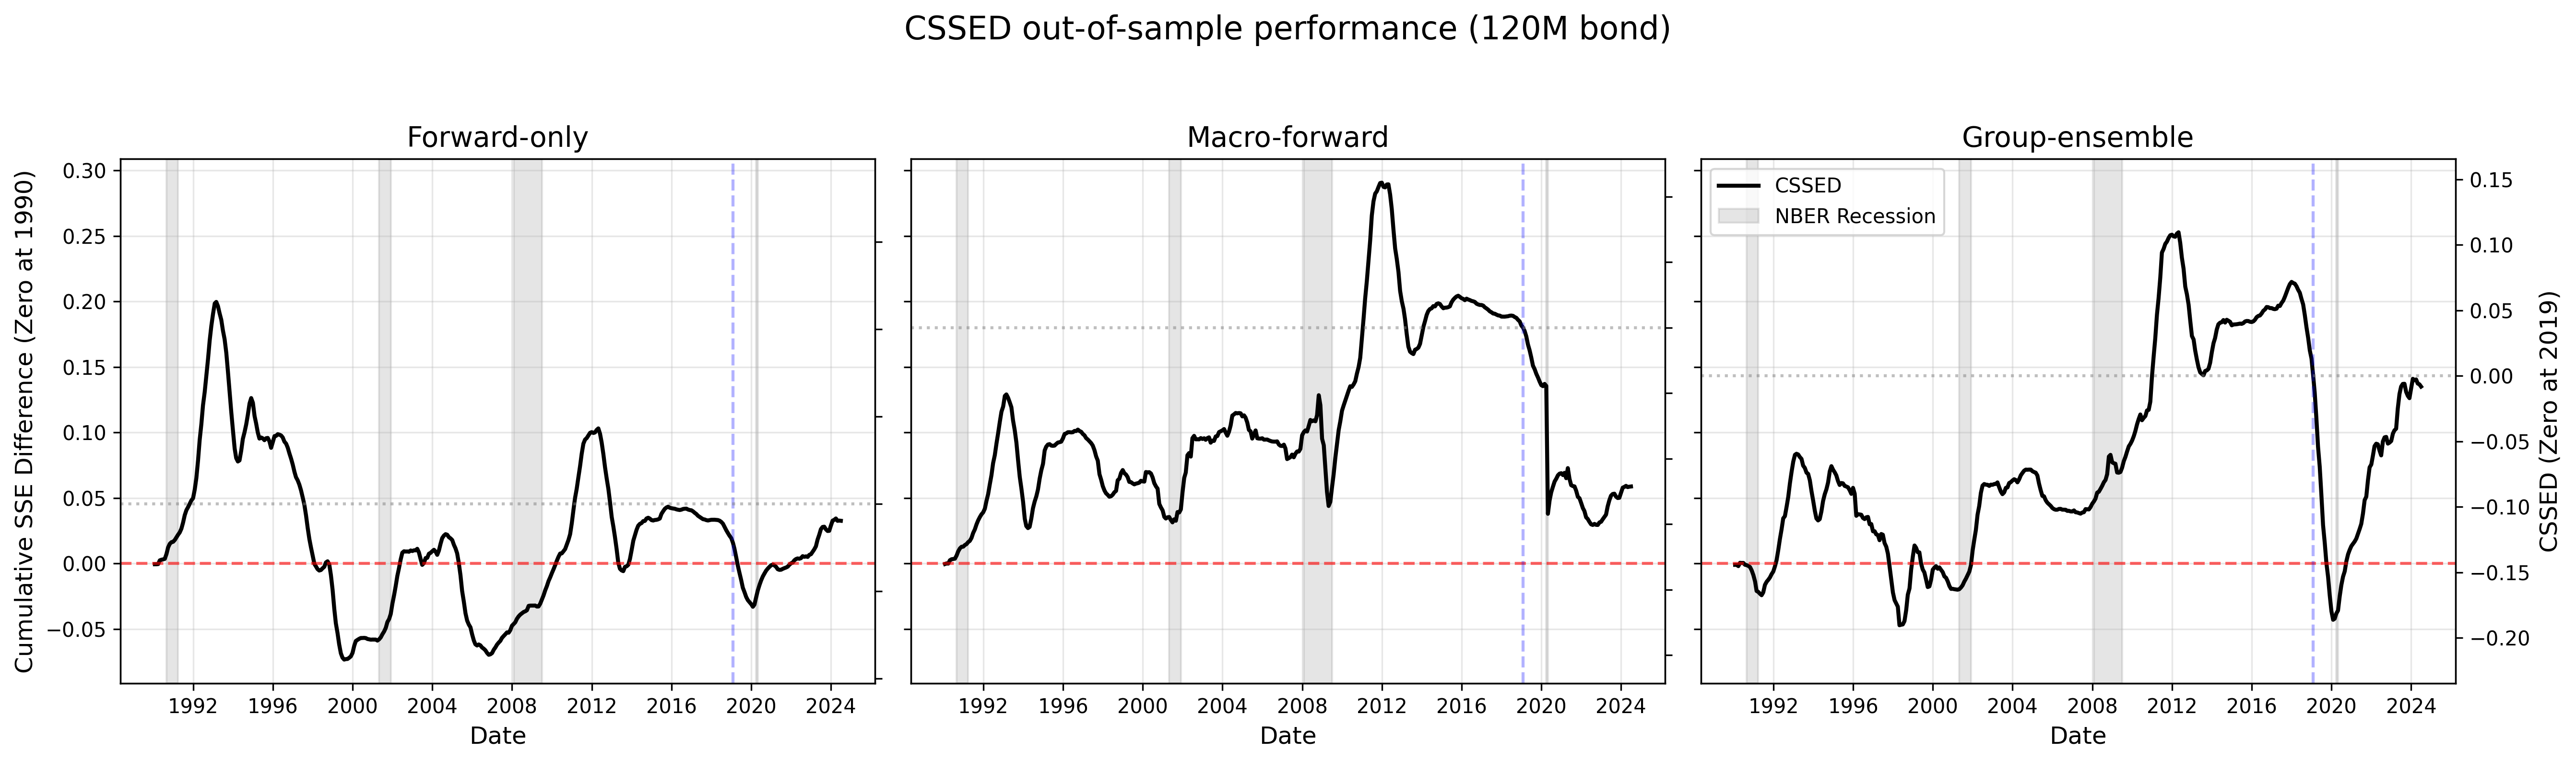

In [24]:
# Set the secondary start for the CSSED plot
secondary_start = pd.Timestamp('2019-01-31')
gap = 11

# Let's plot for 10-year maturity (index -1 corresponds to '120')
mat_idx = -1
print(f"Plotting for Maturity: {target_maturities[mat_idx]} months")

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, dpi=300)
names = ['Forward-only', 'Macro-forward', 'Group-ensemble']
ensembles = [forward_ens, macro_ens, group_ens]

for ax, name, ens in zip(axes, names, ensembles):
    # Align data and filter for OOS period
    df = pd.DataFrame({
        'realized': y_true[:, mat_idx],
        'forecast': ens[:, mat_idx]
    }, index=dates)
    
    oos_df = df.loc[OOS_start_idx:].copy()
    
    # Generate Historical Mean Benchmark (Expanding Window)
    full_series = pd.Series(y_true[:, mat_idx], index=dates)
    oos_df['hist_mean_bench'] = [full_series.loc[:d].iloc[:-1].mean() for d in oos_df.index]
    
    oos_df['error_model'] = (oos_df['realized'] - oos_df['forecast'])**2
    oos_df['error_bench'] = (oos_df['realized'] - oos_df['hist_mean_bench'])**2
    oos_df['cssed'] = (oos_df['error_bench'] - oos_df['error_model']).cumsum()
    
    ax.plot(oos_df.index, oos_df['cssed'], color='black', linewidth=2, label='CSSED')
    ax.axhline(0, color='red', linestyle='--', alpha=0.6)
    
    # Add recession shading
    oos_rec = recession_indicators.reindex(oos_df.index, method='ffill').fillna(0)
    ax.fill_between(oos_df.index, 0, 1, where=(oos_rec['USREC'] == 1), 
                    color='gray', alpha=0.2, transform=ax.get_xaxis_transform(), label='NBER Recession')
    
    ax.set_title(name, fontsize=14)
    ax.set_xlabel('Date', fontsize=12)
    ax.grid(alpha=0.3)
    
    if secondary_start and secondary_start in oos_df.index:
        val_at_secondary = oos_df.loc[secondary_start, 'cssed']
        ax2 = ax.twinx()
        y1_min, y1_max = ax.get_ylim()
        ax2.set_ylim(y1_min - val_at_secondary, y1_max - val_at_secondary)
        ax2.axhline(0, color='gray', linestyle=':', alpha=0.5)
        ax.axvline(secondary_start, color='blue', linestyle='--', alpha=0.3)
        
        # Only add the secondary y-label on the rightmost plot
        if ax == axes[-1]:
            ax2.set_ylabel(f'CSSED (Zero at {secondary_start.year})', fontsize=12)
        else:
            ax2.set_yticklabels([]) # Hide tick labels so it doesn't clutter the middle of the grid
            
    # Add primary y-label only on the leftmost plot
    if ax == axes[0]:
        ax.set_ylabel(f'Cumulative SSE Difference (Zero at {OOS_start_idx.year})', fontsize=12)

# Custom legend on the last ax
custom_lines = [
    Line2D([0], [0], color='black', lw=2),
    mpatches.Patch(color='gray', alpha=0.2)
]
axes[-1].legend(custom_lines, ['CSSED', 'NBER Recession'], loc='best', prop={'size': 10})

fig.suptitle(f'CSSED out-of-sample performance ({target_maturities[mat_idx]}M bond)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## Seed Stability and Disperion 

For a high-quality finance publication, demonstrating the robustness of machine learning models to the random initialization weight (the "seed") is paramount. 
We propose two foundational figures for the paper:

1. **Ensemble Value Add (R2 Distribution Boxplot):** Demonstrates whether the top-10 val loss ensemble merely captures the average performance of the model class, or actively selects superior weights preventing massive downside risk.
2. **Forecast Uncertainty (Spaghetti Plot):** Demonstrates how widely the underlying model predictions diverge during high volatility periods (like the 2020 drop and subsequent recovery).

First, we load the raw individual seed forecasts for all 100 models.

In [25]:
# Load the full (100 seeds) forecast arrays
macro_forecasts_all = np.load(os.path.join(macro_dir, 'forecasts_arr.npy'))
group_forecasts_all = np.load(os.path.join(group_dir, 'forecasts_arr.npy'))

print(f"Shape of macro_forecasts_all: {macro_forecasts_all.shape} (Time, Seeds, Maturities)")

Shape of macro_forecasts_all: (635, 100, 6) (Time, Seeds, Maturities)


## Seed instability visualization

Here we generate the finalized 1x3 grid plots comparing the Forward-only, Macro-Forward, and Group-Ensemble models side-by-side for the three seed instability arguments.

In [26]:
# Prepare data dictionaries for easy 1x3 iteration
model_dirs = {
    'Forward-only': forward_dir,
    'Macro-forward': macro_dir,
    'Group-ensemble': group_dir
}

forecasts_dict = {}
topk_dict = {}
ens_dict = {
    'Forward-only': forward_ens,
    'Macro-forward': macro_ens,
    'Group-ensemble': group_ens
}

for name, mdir in model_dirs.items():
    forecasts_dict[name] = np.load(os.path.join(mdir, 'forecasts_arr.npy'))
    topk_dict[name] = np.load(os.path.join(mdir, 'topk_indices_val_loss.npy'))

# Reconstruct loss_dates and start_plot_idx for the downstream plots
n_time = forecasts_dict['Group-ensemble'].shape[0]
loss_dates = dates[-n_time:]
start_plot_idx = np.where(loss_dates >= pd.Timestamp('2000-01-31'))[0][0]

/tmp/ipykernel_4029563/16693128.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(target_maturities)
/tmp/ipykernel_4029563/16693128.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(target_maturities)
/tmp/ipykernel_4029563/16693128.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(target_maturities)


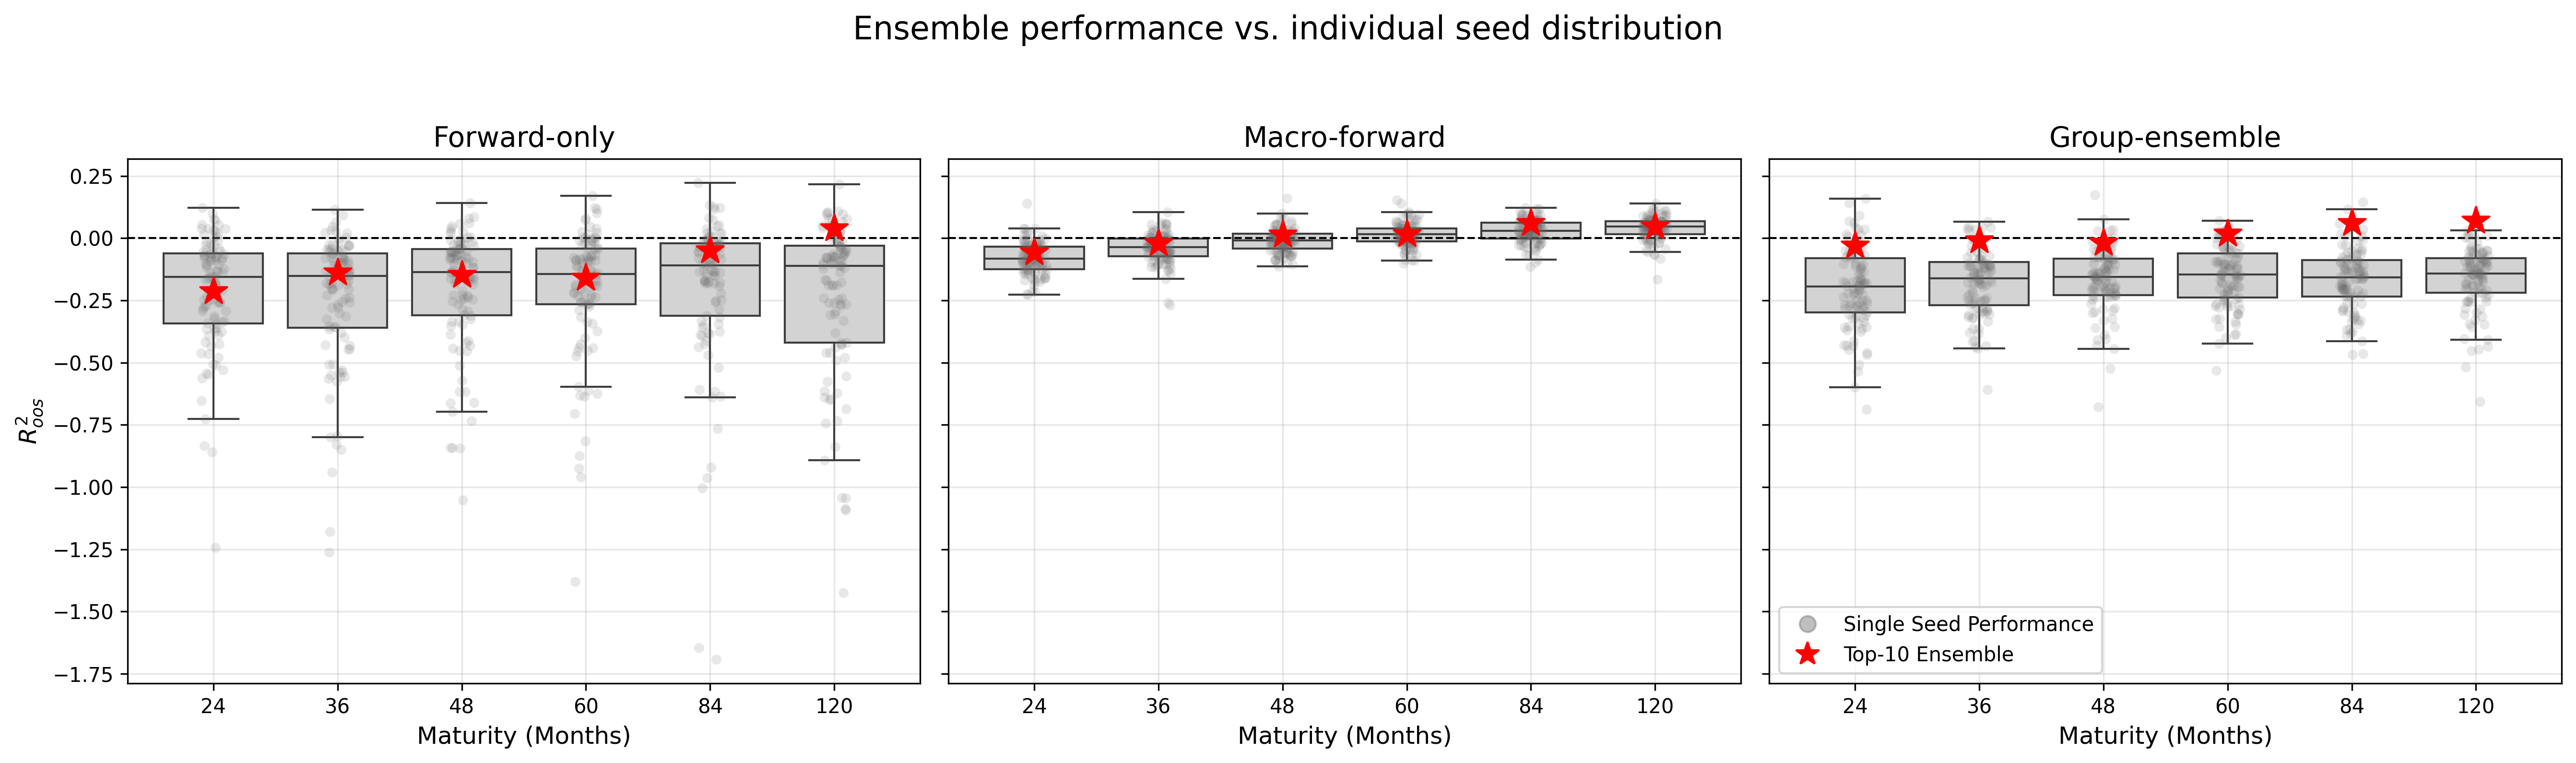

In [27]:
# 1. Ensemble Value Add (Boxplots)
def compute_all_seeds_r2(y_true_full, forecasts_all, gap=11):
    """Calculate Full-Sample OOS R2 for individual seeds across all maturities."""
    n_seeds = forecasts_all.shape[1]
    n_maturities = forecasts_all.shape[2]
    
    all_r2 = np.zeros((n_seeds, n_maturities))
    for s in range(n_seeds):
        for m in range(n_maturities):
            r2 = wu.oos_r2(y_true_full[:, m], forecasts_all[:, s, m], benchmark='hist_mean', gap=gap)
            all_r2[s, m] = r2
    return all_r2

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, dpi=300)

for ax, (name, f_all) in zip(axes, forecasts_dict.items()):
    seeds_r2 = compute_all_seeds_r2(y_true, f_all, gap=11)
    sns.boxplot(data=seeds_r2, ax=ax, color='lightgray', showfliers=False)
    sns.stripplot(data=seeds_r2, ax=ax, alpha=0.15, jitter=True, color='dimgray')
    
    # Overlay ensemble performance
    ens_r2s = [wu.oos_r2(y_true[:, m], ens_dict[name][:, m], benchmark='hist_mean', gap=11) for m in range(len(target_maturities))]
    ax.scatter(range(len(target_maturities)), ens_r2s, color='red', marker='*', s=200, zorder=5)
    
    ax.set_title(name, fontsize=14)
    ax.set_xticklabels(target_maturities)
    ax.set_xlabel('Maturity (Months)', fontsize=12)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('$R^2_{oos}$', fontsize=12)

# Custom legend on the last ax
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='gray', marker='o', linestyle='None', alpha=0.5, markersize=8),
    Line2D([0], [0], color='red', marker='*', linestyle='None', markersize=12)
]
axes[-1].legend(custom_lines, ['Single Seed Performance', 'Top-10 Ensemble'], loc='lower left', prop={'size': 10})

fig.suptitle('Ensemble performance vs. individual seed distribution', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

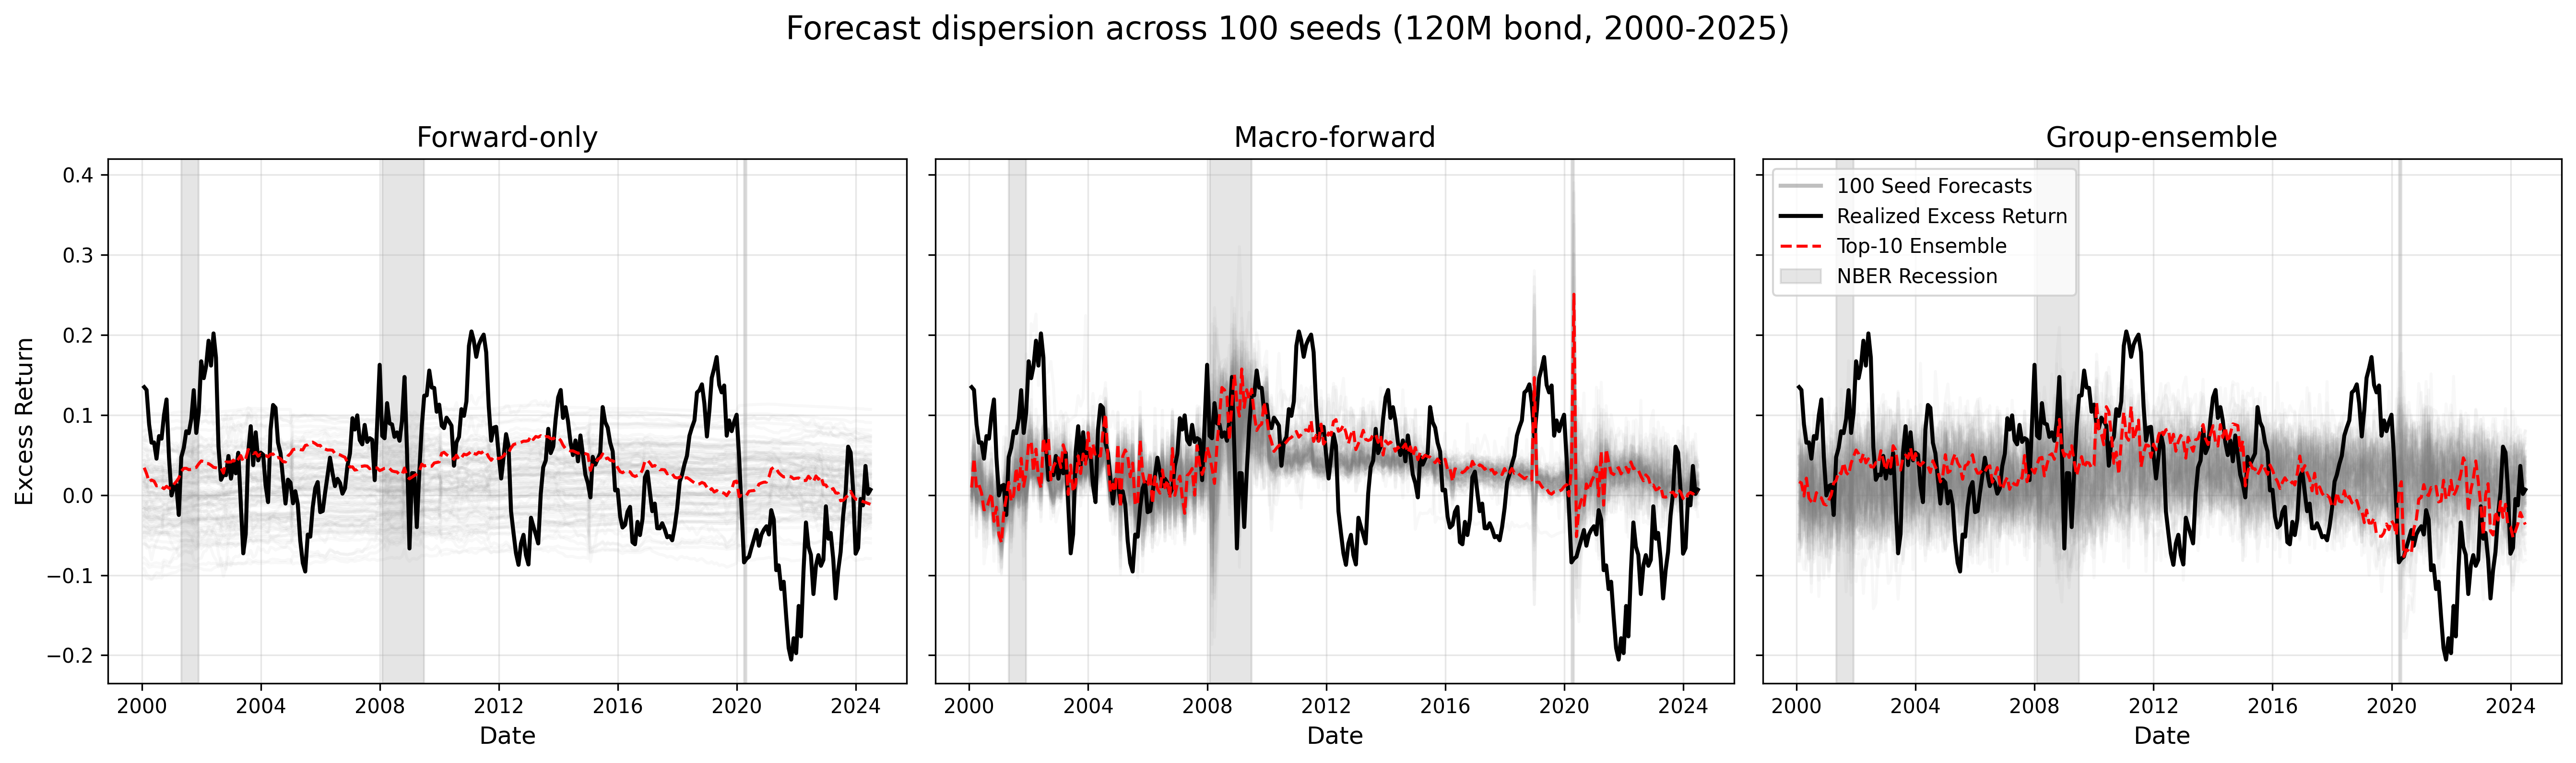

In [28]:
# 2. Forecast Dispersion (Spaghetti Plot)
mat_idx = -1 # 120M
time_subset = loss_dates[start_plot_idx:]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, dpi=300)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

for ax, (name, f_all) in zip(axes, forecasts_dict.items()):
    # Get the time slice starting from 2000-01-31
    # Find the corresponding index in the full dates array to match y_true
    full_date_idx = np.where(dates >= pd.Timestamp('2000-01-31'))[0][0]
    seeds_subset = f_all[full_date_idx:, :, mat_idx]
    
    ax.plot(time_subset, seeds_subset, color='gray', alpha=0.05) 
    ax.plot(time_subset, y_true[full_date_idx:, mat_idx], color='black', linewidth=2)
    ax.plot(time_subset, ens_dict[name][full_date_idx:, mat_idx], color='red', linewidth=1.5, linestyle='--')
    
    # Add recession shading
    rec_subset = recession_indicators.reindex(time_subset, method='ffill').fillna(0)
    ax.fill_between(time_subset, 0, 1, where=(rec_subset['USREC'] == 1), 
                    color='gray', alpha=0.2, transform=ax.get_xaxis_transform())
    
    ax.set_title(name, fontsize=14)
    ax.grid(alpha=0.3)
    ax.set_xlabel('Date', fontsize=12)

axes[0].set_ylabel('Excess Return', fontsize=12)

custom_lines = [
    Line2D([0], [0], color='gray', alpha=0.5, lw=2),
    Line2D([0], [0], color='black', lw=2),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--'),
    mpatches.Patch(color='gray', alpha=0.2)
]
axes[-1].legend(custom_lines, ['100 Seed Forecasts', 'Realized Excess Return', 'Top-10 Ensemble', 'NBER Recession'], loc='upper left', prop={'size': 10})

fig.suptitle(f'Forecast dispersion across 100 seeds ({target_maturities[mat_idx]}M bond, 2000-2025)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

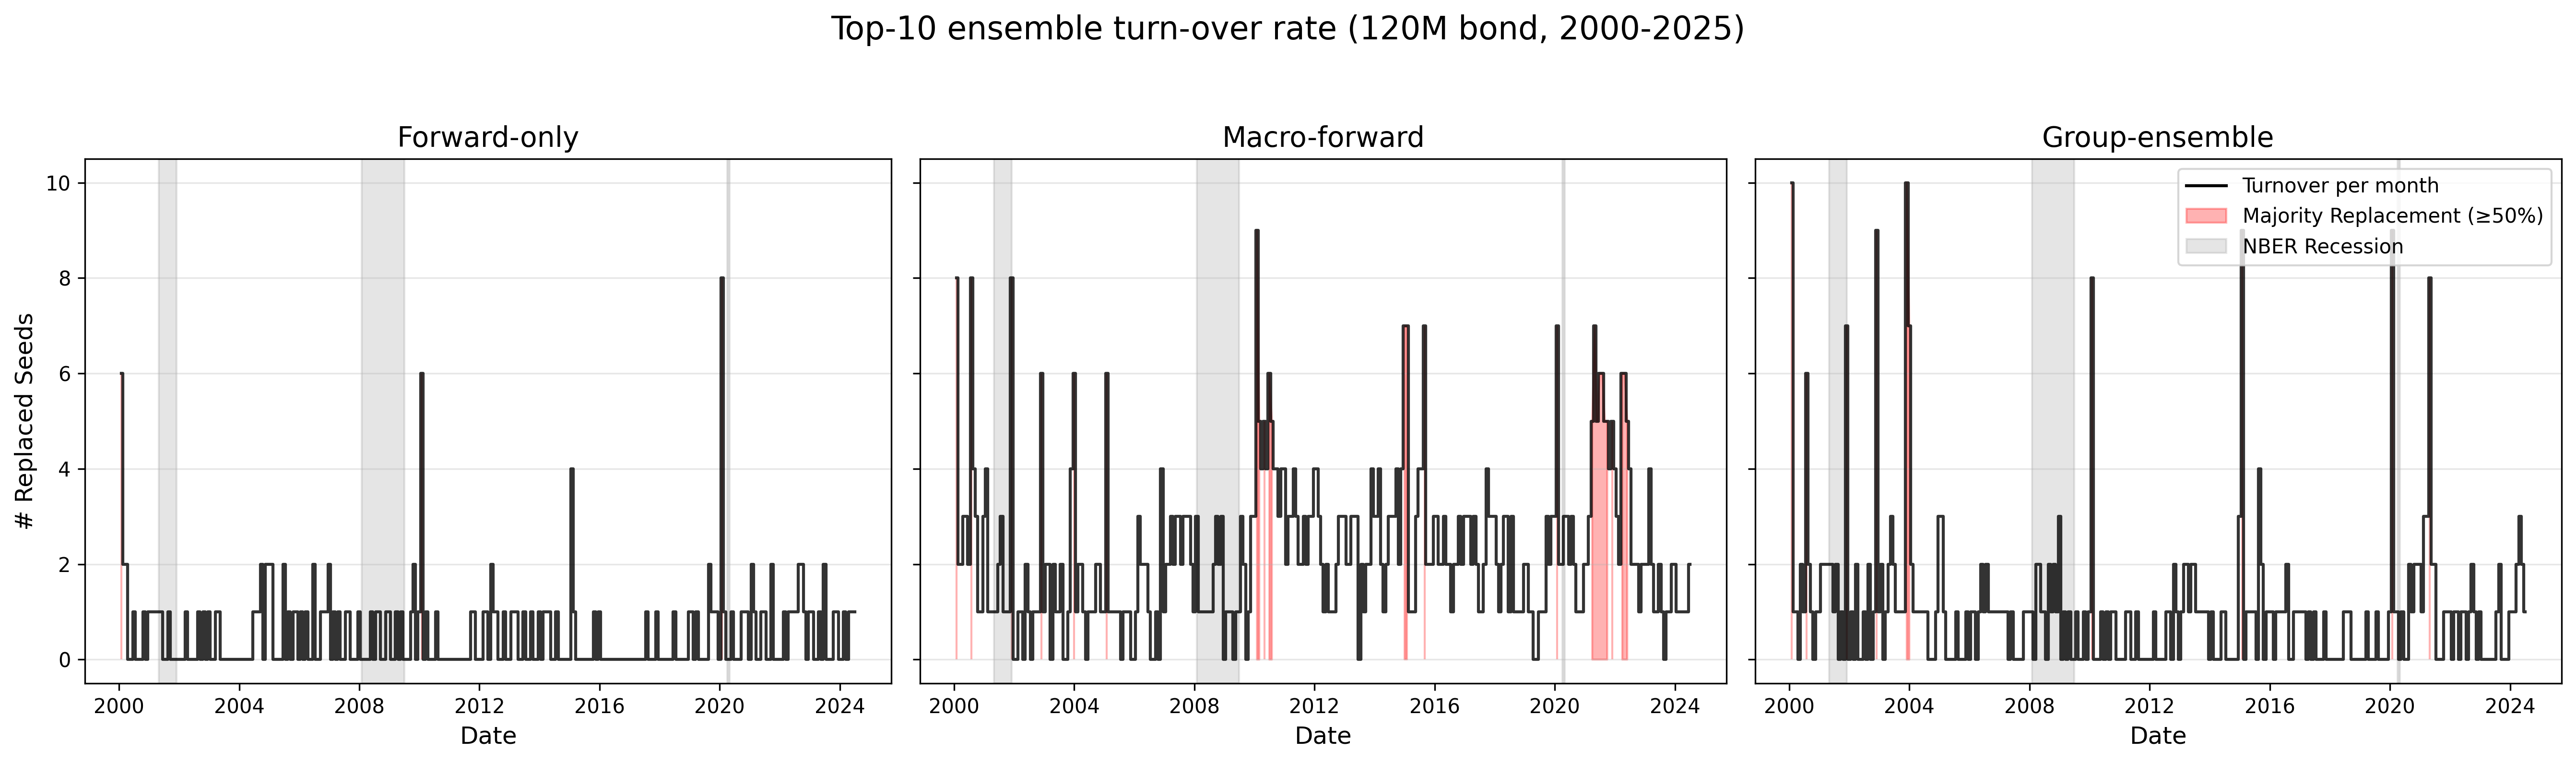

In [29]:
# 3. Ensemble Turnover / Churn Rate (1x3 Grid)
mat_idx = -1
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, dpi=300)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

for ax, (name, t_idx) in zip(axes, topk_dict.items()):
    n_time = t_idx.shape[0]
    turnover = np.zeros(n_time)
    
    for t in range(1, n_time):
        prev_topk = set(t_idx[t-1, mat_idx, :])
        curr_topk = set(t_idx[t, mat_idx, :])
        turnover[t] = len(curr_topk - prev_topk)
        
    time_subset = loss_dates[start_plot_idx:]
    ax.plot(time_subset, turnover[start_plot_idx:], color='black', drawstyle='steps-mid', alpha=0.8)
    
    ax.set_title(name, fontsize=14)
    ax.set_xlabel('Date', fontsize=12)
    
    # Shade periods of high instability
    high_turnover_mask = turnover[start_plot_idx:] >= 5
    ax.fill_between(time_subset, 0, turnover[start_plot_idx:], where=high_turnover_mask, color='red', alpha=0.3)
    
    # Add recession shading
    rec_subset = recession_indicators.reindex(time_subset, method='ffill').fillna(0)
    ax.fill_between(time_subset, 0, 1, where=(rec_subset['USREC'] == 1), 
                    color='gray', alpha=0.2, transform=ax.get_xaxis_transform())
    
    ax.set_yticks(np.arange(0, 11, 2))
    ax.grid(alpha=0.3, axis='y')

axes[0].set_ylabel('# Replaced Seeds', fontsize=12)

# Custom legend on the last ax
custom_patches = [
    Line2D([0], [0], color='black', lw=1.5, drawstyle='steps-mid'),
    mpatches.Patch(color='red', alpha=0.3),
    mpatches.Patch(color='gray', alpha=0.2)
]
axes[-1].legend(custom_patches, ['Turnover per month', 'Majority Replacement (≥50%)', 'NBER Recession'], loc='upper right', prop={'size': 10})

fig.suptitle(f'Top-10 ensemble turn-over rate ({target_maturities[mat_idx]}M bond, 2000-2025)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()